# Sistemas Inteligentes - 2026.1
## Projeto 01 - Regressão Linear Múltipla
Autores: Lavínia Dantas e Jefferson Bezerra


## Contexto

Este projeto tem como objetivo construir um modelo de regressão linear múltipla para prever a produção de energia elétrica (PE) de uma usina termoelétrica de ciclo combinado, com base em variáveis ambientais utilizando o dataset Combined Cycle Power Plant (UCI)

## Preparação do Ambiente de Trabalho

In [ ]:
# Biblioteca principal para trabalhar com dados em formato de tabela
import pandas as pd
# Biblioteca para computação numérica eficiente
import numpy as np

# Importa a função responsável por baixar o dataset
from ucimlrepo import fetch_ucirepo

# Biblioteca base para criação de gráficos
import matplotlib.pyplot as plt
# Biblioteca baseada no matplotlib, mais avançada e bonita
import seaborn as sns

# Função que divide os dados em treino e teste
from sklearn.model_selection import train_test_split
# Implementação do modelo de regressão linear
from sklearn.linear_model import LinearRegression
# Métricas de avaliação do modelo: erro absoluto médio, erro quadrático médio e
# qualidade do ajuste do modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

####Opção 1 - Obtenção dos dados pelo reopsitório UCI

In [ ]:
pip install ucimlrepo

In [ ]:
# Faz o download do dataset, 294 = repositório UCI
#dataset = fetch_ucirepo(id=294)

# X = Variáveis independentes (features)
# AT (temperatura), V (vácuo), AP (pressão), RH (umidade)
# Y = Variável dependente (target)
# PE (produção de energia elétrica)
#X = dataset.data.features
#y = dataset.data.targets

# Unificar em um único DataFrame
#df = X.copy()
#df['PE'] = y

#df.head()

### Opção 2 - Obtenção dos dados pelo KagleHub

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 1. Definimos o nome real do arquivo dentro do dataset
# Neste caso, o arquivo se chama 'Folds5x2_pp.xlsx'
file_path = "Power Plant Data.csv"

# 2. Usamos dataset_load (a versão mais recente da função)
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rinichristy/combined-cycle-power-plant-data-set-uci-data",
  file_path,
)

# 3. Separando os dados (O df já vem pronto do kagglehub)
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

print("Dataset carregado com sucesso!")
print(df.head())

print("\nFormato de X (Features):", X.shape)
print("Formato de y (Target):", y.shape)

100%|██████████| 311k/311k [00:00<00:00, 32.4MB/s]

Dataset carregado com sucesso!
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

Formato de X (Features): (9568, 4)
Formato de y (Target): (9568,)


## 1 - Cálculo da correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE).

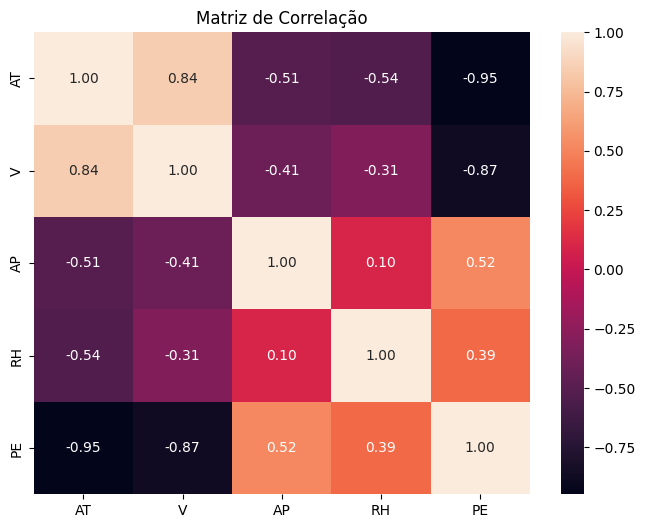

In [ ]:
correlacao = df.corr()
correlacao['PE'].sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.heatmap(correlacao, annot=True, fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

A análise da matriz de mostra que a AT apresenta a maior influência sobre a produção de energia (PE), com uma forte correlação negativa (-0.95), seguida por V (-0.87).

As variáveis AP (0.52) e RH (0.39) apresentam correlações positivas, porém mais fracas

Foi deduzido que a temperatura ambiente é o fator mais determinante na previsão da produção de energia, sendo inversamente proporcional ao desempenho da usina.

##2 - Cálculo da correlação das variáveis independentes (AT, V, AP, RH) entre si.

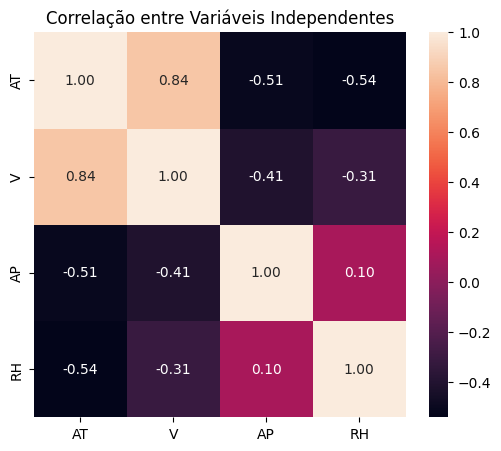

In [ ]:
variaveis = df[['AT', 'V', 'AP', 'RH']]

plt.figure(figsize=(6,5))
sns.heatmap(variaveis.corr(), annot=True, fmt=".2f")
plt.title("Correlação entre Variáveis Independentes")
plt.show()

A análise da correlação entre as variáveis independentes indica a presença de uma forte correlação positiva entre AT e V (0.84) que pode gerar multicolinearidade, as demais variáveis apresentam correlações moderadas ou fracas, não representando risco significativo.

Apesar da presença de uma correlação relativamente forte entre as variáveis AT e V, optou-se por manter ambas no modelo, elas são fenomenos físicos distintos no funcionamento da usina, além de que já que não chegou aos 0.90, o impacto não será relevante na capacidade preditiva.


##3 - Construção do modelo de regressao linear múltipla utilizando AT, V, AP e RH para prever PE

In [ ]:
# Dividindo os dados (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Definindo o modelo de regressão linear
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X_train, y_train)

# Organização dos coeficientes numa tabela
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_.flatten()
})
coeficientes

,Variável,Coeficiente
0,AT,-1.985900
1,V,-0.232094
2,AP,0.062200
3,RH,-0.158118


## 4 - Avaliação do desempenho do modelo utilizando as métricas R², RMSE e MAE.

In [ ]:
# Prevendo os valores usando o conjunto de teste
y_pred = modelo.predict(X_test)

# MAE (Erro Absoluto Médio)
mae = mean_absolute_error(y_test, y_pred)

# RMSE (Raiz do Erro Quadrático Médio)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² (Coeficiente de determinação)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.595913178273408
RMSE: 4.502633229532186
R²: 0.9301046431962188


Os resultados obtidos indicam que o modelo apresenta alto desempenho na tarefa de predição. O coeficiente de determinação (R² = 0.93) demonstra que o modelo é capaz de explicar aproximadamente 93% da variabilidade da produção de energia elétrica.

Além disso, os valores de MAE (3.59) e RMSE (4.50) são relativamente baixos, indicando que os erros de previsão são pequenos quando comparados à escala dos dados. A proximidade entre MAE e RMSE sugere ainda que não há presença significativa de erros extremos.

Resumindo, o modelo de regressão linear múltipla é adequado e eficaz para a previsão da produção de energia no contexto analisado e com os dados disponíveis.

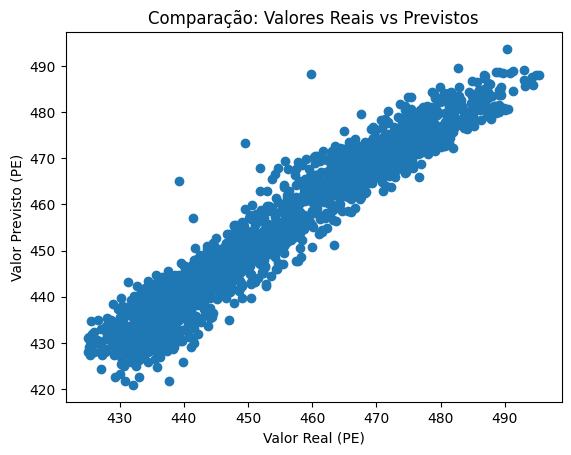

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valor Real (PE)")
plt.ylabel("Valor Previsto (PE)")
plt.title("Comparação: Valores Reais vs Previstos")
plt.show()

O gráfico de dispersão entre os valores reais e previstos demonstra que os pontos se distribuem próximos de uma linha diagonal, indicando forte concordância entre as previsões do modelo e os valores observados.

A baixa dispersão dos pontos sugere que os erros são reduzidos, corroborando os resultados obtidos pelas métricas quantitativas. Não foram observados padrões anômalos ou desvios sistemáticos significativos, o que indica que o modelo consegue capturar adequadamente a relação entre as variáveis, reforçando as análises anteriores.